In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pathlib import Path

In [ ]:
# ---------- 参数 ----------
# 数据
PROJECT_ROOT = Path.cwd().parent
CSV_IN=PROJECT_ROOT/"data/boueguer_frenquency_11km.csv"
CSV_OUT=PROJECT_ROOT/"data/boueguer_frenquency_11km_1deg.csv"

# 区域：165E 到 170W(=-170), 10N 到 30N
LON_MIN, LON_MAX = -180, 180
LAT_MIN, LAT_MAX = -90, 90

DLON = 1.0
DLAT = 1.0

# 你要画/处理的变量列
VALUE_COLS = ["topo", "deltaN"]

In [7]:
# ---------- 工具函数 ----------
def lon_to_0360(lon):
    return np.mod(lon, 360.0)

def lon_to_180(lon):
    """转到 [-180, 180)"""
    return ((lon + 180) % 360) - 180

def subset_region_dateline_safe(df, lon_min_any, lon_max_any, lat_min, lat_max):
    """
    先把 lon 统一到 [0,360)，再用 lon_min~lon_max（也映射到[0,360)）裁剪。
    适合你的这种跨 180° 的范围（比如 165 到 -170）。
    """
    df = df.copy()
    df["lon"] = lon_to_0360(df["lon"].values)

    lon_min = lon_to_0360(lon_min_any)
    lon_max = lon_to_0360(lon_max_any)

    if lon_min <= lon_max:
        lon_mask = (df["lon"] >= lon_min) & (df["lon"] <= lon_max)
    else:
        # 跨 0° 经线（本例不是，但顺手兼容）
        lon_mask = (df["lon"] >= lon_min) | (df["lon"] <= lon_max)

    lat_mask = (df["lat"] >= lat_min) & (df["lat"] <= lat_max)

    sub = df.loc[lon_mask & lat_mask].copy()
    return sub

def resample_to_grid(df, value_cols, dlon=0.25, dlat=0.25, agg="mean"):
    df = df.copy()
    value_cols = [c for c in value_cols if c in df.columns]
    if not value_cols:
        raise ValueError(f"没找到要处理的列: {value_cols}")

    df["lon_bin"] = np.floor(df["lon"].values / dlon) * dlon
    df["lat_bin"] = np.floor(df["lat"].values / dlat) * dlat

    if agg == "mean":
        out = df.groupby(["lon_bin", "lat_bin"], as_index=False)[value_cols].mean()
    elif agg == "median":
        out = df.groupby(["lon_bin", "lat_bin"], as_index=False)[value_cols].median()
    else:
        raise ValueError("agg 只支持 mean 或 median")

    out = out.rename(columns={"lon_bin": "lon", "lat_bin": "lat"})
    out = out.sort_values(["lat", "lon"]).reset_index(drop=True)
    return out

def to_grid(df, value_col):
    g = df.pivot(index="lat", columns="lon", values=value_col)
    lats = g.index.values
    lons = g.columns.values
    Z = g.values
    LON, LAT = np.meshgrid(lons, lats)
    return LON, LAT, Z

def plot_panel(ax, df, value_col, title, extent_lonlat, vmin=None, vmax=None):
    """
    extent_lonlat 用的是 [-180,180) 的经度体系，且允许 lon_min > lon_max 表示跨 180°
    """
    data_crs = ccrs.PlateCarree()
    ax.set_extent([extent_lonlat[0], extent_lonlat[1], extent_lonlat[2], extent_lonlat[3]], crs=data_crs)

    LON, LAT, Z = to_grid(df, value_col)
    im = ax.pcolormesh(LON, LAT, Z, transform=data_crs, shading="auto", vmin=vmin, vmax=vmax)

    ax.gridlines(draw_labels=True, linewidth=0.4, alpha=0.5)
    ax.set_title(title)
    return im



In [14]:
df0 = pd.read_csv(CSV_IN)

need = {"lon", "lat"} | set(VALUE_COLS)
missing = need - set(df0.columns)
if missing:
    raise ValueError(f"输入CSV缺少列：{missing}\n当前列：{list(df0.columns)}")

# 1) 裁剪（内部用 0~360）
df_raw = subset_region_dateline_safe(df0, LON_MIN, LON_MAX, LAT_MIN, LAT_MAX)
if df_raw.empty:
    raise ValueError("裁剪后为空：检查数据覆盖范围是否包含该区域。")

# 2) 降采样到 0.25°
df_ds = resample_to_grid(df_raw, VALUE_COLS, dlon=DLON, dlat=DLAT, agg="mean")

# 3) 保存（你之前同格式：lon,lat,topo,deltaN...，不写index）
df_ds.to_csv(CSV_OUT, index=False)
print(f"已保存降采样CSV: {CSV_OUT}  shape={df_ds.shape}")

ValueError: 裁剪后为空：检查数据覆盖范围是否包含该区域。

In [10]:
df0

,lat,lon,deltaN,topo
0,-89.9375,0.06250,82.794528,1283.856922
1,-89.9375,0.18750,82.795226,1283.458169
2,-89.9375,0.31250,82.795929,1283.054885
3,-89.9375,0.43750,82.796637,1282.647065
4,-89.9375,0.56250,82.797349,1282.234701
...,...,...,...,...
4147195,89.9375,359.43749,3.854510,365.952329
4147196,89.9375,359.56249,3.856040,365.403316
4147197,89.9375,359.68749,3.857569,364.853629
4147198,89.9375,359.81249,3.859098,364.303274


In [ ]:
import xarray as xr

def df_to_da(df, value_col, lat_col="lat", lon_col="lon", sort=True):
    """
    df: 必须包含 lon/lat/value_col
    返回：xarray.DataArray，dims=('lat','lon')，coords 带真实 lat/lon
    """
    # pivot 成 2D
    g = df.pivot(index=lat_col, columns=lon_col, values=value_col)

    # 确保经纬度是数值类型（很关键，不然排序/meshgrid容易出坑）
    g.index = g.index.astype(float)
    g.columns = g.columns.astype(float)

    if sort:
        g = g.sort_index(axis=0)   # lat 升序
        g = g.sort_index(axis=1)   # lon 升序

    da = xr.DataArray(
        g.values,
        dims=("lat", "lon"),
        coords={"lat": g.index.values, "lon": g.columns.values},
        name=value_col
    )
    return da

# ---- 生成四个 DataArray ----
# 这里假设你已经有：
# df_raw_plot / df_ds_plot  （注意：用于画图的版本，lon 已经转到 [-180,180) 或者你想画的体系）
topo_raw_da   = df_to_da(df_raw, "topo")
topo_ds_da    = df_to_da(df_ds,  "topo")
dN_raw_da = df_to_da(df_raw, "deltaN")
dN_ds_da  = df_to_da(df_ds,  "deltaN")

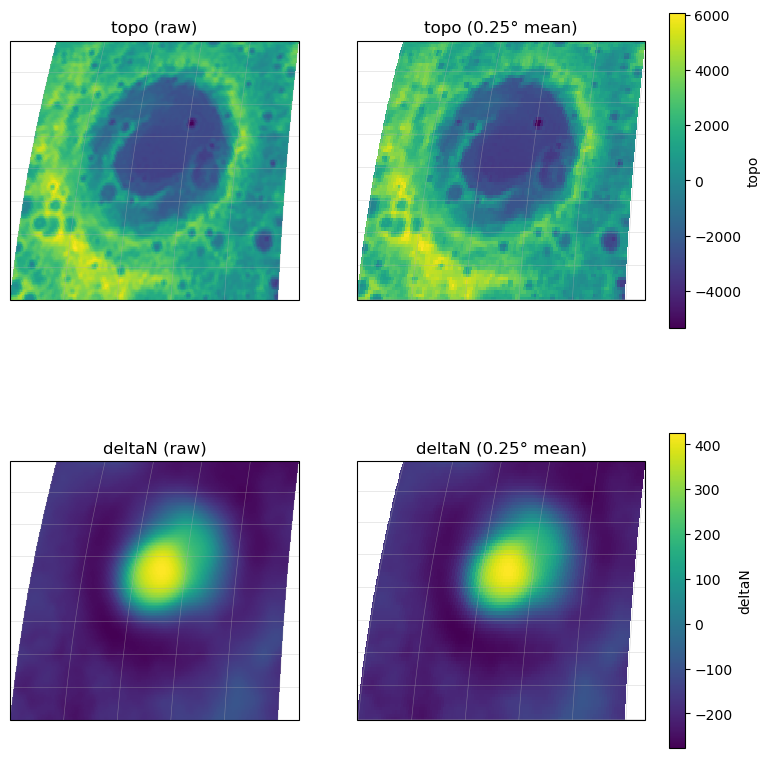

In [ ]:
fig = plt.figure(figsize=(10, 10))

# 关键：用 central_longitude=180，让跨180°的区域连续
map_crs  = ccrs.Mollweide(central_longitude=180)
data_crs = ccrs.PlateCarree()

def plot_da(ax, da, title, vmin=None, vmax=None):
    lons = da.lon.values
    lats = da.lat.values
    Z = da.values

    LON, LAT = np.meshgrid(lons, lats)

    im = ax.pcolormesh(
        LON, LAT, Z,
        transform=data_crs,
        shading="auto",
        vmin=vmin, vmax=vmax
    )
    ax.set_title(title)
    ax.gridlines(draw_labels=False, linewidth=0.4, alpha=0.5)
    return im

# ---- 你需要准备四个 DataArray ----
# topo_raw_da, topo_ds_da, dN_raw_da, dN_ds_da
# (如果你目前只有 df，可以我再给你一个 df->DataArray 的小函数)

ax1 = fig.add_subplot(2, 2, 1, projection=map_crs)
m1 = plot_da(ax1, topo_raw_da, "topo (raw)")

ax2 = fig.add_subplot(2, 2, 2, projection=map_crs)
m2 = plot_da(ax2, topo_ds_da, "topo (0.25° mean)")

ax3 = fig.add_subplot(2, 2, 3, projection=map_crs)
m3 = plot_da(ax3, dN_raw_da, "deltaN (raw)")

ax4 = fig.add_subplot(2, 2, 4, projection=map_crs)
m4 = plot_da(ax4, dN_ds_da, "deltaN (0.25° mean)")

# 两个 colorbar：topo 用 m1，deltaN 用 m3
cb1 = fig.colorbar(m1, ax=[ax1, ax2], shrink=0.9, pad=0.03)
cb1.set_label("topo")

cb2 = fig.colorbar(m3, ax=[ax3, ax4], shrink=0.9, pad=0.03)
cb2.set_label("deltaN")

plt.show()